## Regresion logistica

In [1]:
import awswrangler as wr

import mlflow

# Para que funciones, todos nuestros scripts debemos exportar las siguientes variables de entorno
%env AWS_ACCESS_KEY_ID=minio   
%env AWS_SECRET_ACCESS_KEY=minio123 
%env MLFLOW_S3_ENDPOINT_URL=http://localhost:9000
%env AWS_ENDPOINT_URL_S3=http://localhost:9000
#%env MLFLOW_S3_ENDPOINT_URL=http://192.168.0.21:9000
#%env AWS_ENDPOINT_URL_S3=http://192.168.0.21:9000

env: AWS_ACCESS_KEY_ID=minio
env: AWS_SECRET_ACCESS_KEY=minio123
env: MLFLOW_S3_ENDPOINT_URL=http://localhost:9000
env: AWS_ENDPOINT_URL_S3=http://localhost:9000


In [2]:
import awswrangler as wr

import mlflow
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from astropy.time import Time
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import optuna
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
mlflow_server = "http://localhost:5001"
mlflow.set_tracking_uri(mlflow_server)

In [4]:
data_path = "s3://data/star_classification.csv"
data_raw =  wr.s3.read_csv("s3://data/star_classification.csv")

In [5]:
data = wr.s3.read_csv("s3://data/data.csv")

In [6]:
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)
# Print the shapes of the resulting DataFrames
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

# Now you can work with train_df and test_df for training and evaluation
X_train = train_df.drop(['class'], axis=1)
y_train = train_df['class']
X_test = test_df.drop(['class'], axis=1)
y_test = test_df['class']

Training set shape: (80000, 11)
Testing set shape: (20000, 11)


In [7]:
numerical_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift", "Month"]
#categorical_cols = ["class", "cam_col"]

scaler = StandardScaler()

train_df_norm = scaler.fit_transform(X_train[numerical_cols])

test_df_norm = scaler.transform(X_test[numerical_cols])

Modelo con hiperparametros default

In [8]:
experiment_name = "LogReg_Grif"

if not mlflow.get_experiment_by_name(experiment_name):
    mlflow.create_experiment(name=experiment_name) 

experiment = mlflow.get_experiment_by_name(experiment_name)

In [9]:
logit = LogisticRegression()
df_train = pd.DataFrame(train_df_norm, columns=numerical_cols)
df_test = pd.DataFrame(test_df_norm, columns=numerical_cols)
logit.fit(df_train[numerical_cols], y_train)
y_pred = logit.predict(df_test[numerical_cols])
print("Reporte de clasificación:")
print(classification_report(test_df["class"], y_pred))

print("Precisión del modelo:", accuracy_score(test_df["class"], y_pred))

/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Reporte de clasificación:
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96     11860
         QSO       0.94      0.87      0.91      3797
        STAR       0.94      1.00      0.97      4343

    accuracy                           0.95     20000
   macro avg       0.95      0.94      0.95     20000
weighted avg       0.95      0.95      0.95     20000

Precisión del modelo: 0.95305


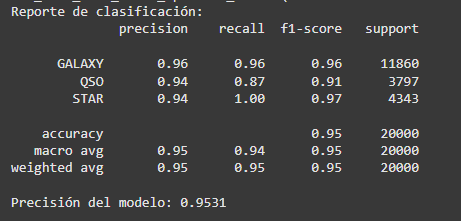

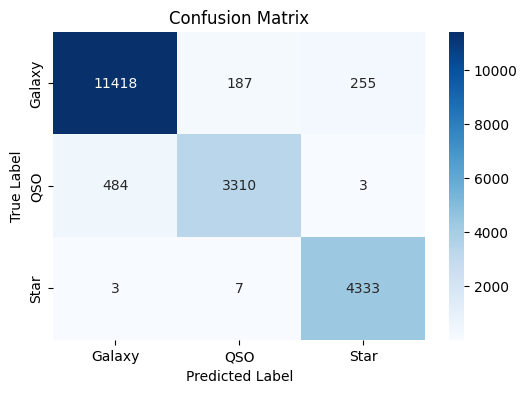

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Galaxy', 'QSO', 'Star'], yticklabels=['Galaxy', 'QSO', 'Star'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Modelo con hiperparametros optimizados encontrados mediante busqueda en grilla

In [11]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

modelLogis = LogisticRegression()

param_grid = {
    'penalty': [None],
    'solver': ['newton-cg'],
    'C': [0.01],
    'l1_ratio': [1.0]} # Power parameter for the Minkowski metric
grid_search = GridSearchCV(modelLogis, param_grid, cv=5, refit = 'accuracy', return_train_score = True, scoring = 'accuracy',  n_jobs=-1)

grid_search.fit(train_df_norm, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_model_rl = grid_search.best_estimator_
y_pred_logis = best_model_rl.predict(test_df_norm)
y_proba_logis = best_model_rl.predict_proba(test_df_norm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_logis))
print("Test Accuracy:", accuracy_score(y_test, y_pred_logis))

/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Go

Best Parameters: {'C': 0.01, 'l1_ratio': 1.0, 'penalty': None, 'solver': 'newton-cg'}
Best Score: 0.962575

Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     11860
         QSO       0.95      0.88      0.91      3797
        STAR       0.98      1.00      0.99      4343

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.96     20000
weighted avg       0.96      0.96      0.96     20000

Test Accuracy: 0.96235


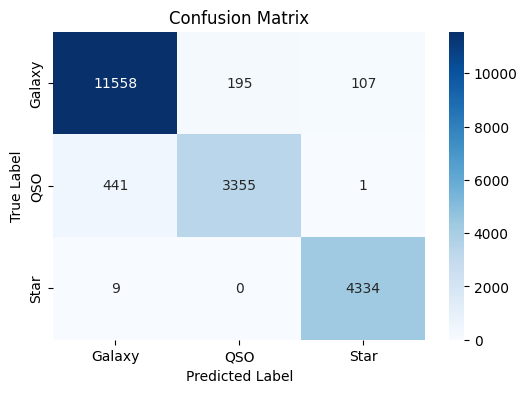

In [12]:
cm = confusion_matrix(y_test, y_pred_logis)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Galaxy', 'QSO', 'Star'], yticklabels=['Galaxy', 'QSO', 'Star'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Los resultados de regresion logistica ya son muy buenos, por lo que al tener tan buenos resultados con un modelo simple podriamos quedarnos con este. Sin embargo, vamos a probar 3 clasificadores mas y comparar resultados: KNN, SVM y XGBoost.

In [13]:
print(f'Los mejores parámetros son: {grid_search.best_params_}')

Los mejores parámetros son: {'C': 0.01, 'l1_ratio': 1.0, 'penalty': None, 'solver': 'newton-cg'}


In [14]:
report = classification_report(y_test, y_pred_logis, output_dict=True)
print(report.keys())

dict_keys(['GALAXY', 'QSO', 'STAR', 'accuracy', 'macro avg', 'weighted avg'])


In [15]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, classification_report
from plot2 import plot_confusion_matrix, plot_roc_curve

# Make sure we're using the Star Classification experiment
experiment = mlflow.set_experiment("Star Classification")

with mlflow.start_run(experiment_id=experiment.experiment_id):
    # Set a tag indicating this is the champion model
    mlflow.set_tag("model_status", "champion")
    
    # Log the best hyperparameters
    mlflow.log_params(grid_search.best_params_)
    
    # Get predictions from the evaluation dataset
    y_pred = grid_search.predict(test_df_norm)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_logis)
    precision = precision_score(y_test, y_pred_logis, average='weighted')
    recall = recall_score(y_test, y_pred_logis, average='weighted')
    print(f'Accuracy: {accuracy}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    
    report = classification_report(y_test, y_pred_logis, output_dict=True)

    class_labels = [k for k in report.keys() if k not in ('accuracy', 'macro avg', 'weighted avg')]
    
    metrics = {}

    for cls in class_labels:
        metrics[f'precision_class_{cls}'] = report[cls]['precision']
        metrics[f'recall_class_{cls}'] = report[cls]['recall']
        
    metrics['accuracy'] = report['accuracy']    

    mlflow.log_metrics(metrics)    
    # Log the confusion matrix and ROC curve
    matrix_plot = plot_confusion_matrix(y_test, y_pred_logis, save_path=None)
    roc_plot = plot_roc_curve(y_test, y_proba_logis, save_path=None)
    
    mlflow.log_figure(matrix_plot, artifact_file="matrix_plot.png")
    
    # Register the model with a name that the DAG will look for
    mlflow.sklearn.log_model(
        sk_model=grid_search,
        artifact_path="LogReg_Grif",
        registered_model_name="star_classification_model"
    )

Accuracy: 0.96235
Precision: 0.9620692860347172
Recall: 0.96235


/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/Users/pedrobarrera/MLOps/py38_env/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
Registered model 'star_classification_model' already exists. Creating a new version of this model...
2025/05/03 23:24:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: star_classification_model, version 10
Created version '10' of model 'star_classification_model'.
